In [140]:
import PhidgetUtils
from sensor_fusion.height import calculate_height
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tkinter as tk
from tkinter import messagebox
from tkinter import ttk
import uuid
import os

from time import sleep

In [141]:
acc = PhidgetUtils.PhidgetAccelerometer(data_rate=60)

while not acc.is_attached():
    sleep(0.1)

print("Accelerometer is attached!")

Accelerometer is attached!


In [142]:
def magnitude(v):
    return v[0] * v[0] + v[1] * v[1] + v[2] * v[2]

def sign(v):
    return 1 if v > 0 else -1

In [143]:
RECORDING = False
df = pd.DataFrame({"timestamp": [], "acceleration": []})
prev_acc = -1
prev_pressure = -1

root = tk.Tk()
root.title("Accelerometer + Barometer Measurements")
root.geometry("400x250")
root.resizable(False, False)

''

In [135]:
start_button = stop_button = None

def start():
    global RECORDING
    RECORDING = True
    stop_button.config(state=tk.NORMAL)
    start_button.config(state=tk.DISABLED)
    record()

def stop():
    global RECORDING
    RECORDING = False
    stop_button.config(state=tk.DISABLED)
    start_button.config(state=tk.NORMAL)

def record():
    global prev_acc
    global prev_pressure
    global df
    if RECORDING:
        if acc.getAcceleration() != prev_acc: # or barometer
            df.loc[len(df)] = {
                "timestamp": acc.getTimestamp(),
                "acceleration": magnitude(acc.getAcceleration()) * sign(acc.getAcceleration()[2])
            }
            prev_acc = acc.getAcceleration()
            
        root.after(17, record)

In [136]:
# Styling with ttk
style = ttk.Style()
style.configure("TButton", font=("Arial", 12), padding=10)
style.configure("TLabel", font=("Arial", 14))
style.configure("TFrame", background="#f0f0f0")

# Main frame
frame = ttk.Frame(root, padding=20, style="TFrame")
frame.pack(expand=True, fill=tk.BOTH)

# Title Label
title_label = ttk.Label(
    frame, text="Accelerometer + Barometer", font=("Arial", 16, "bold")
)
title_label.pack(pady=10)

# Status Label
status_label = ttk.Label(frame, text="Ready to Start", foreground="blue")
status_label.pack(pady=10)

# Buttons
button_frame = ttk.Frame(frame, padding=10, style="TFrame")
button_frame.pack(pady=20)

start_button = ttk.Button(button_frame, text="Start", command=start)
start_button.grid(row=0, column=0, padx=10)

stop_button = ttk.Button(button_frame, text="Stop", command=stop, state=tk.DISABLED)
stop_button.grid(row=0, column=1, padx=10)

# Run the application
root.mainloop()


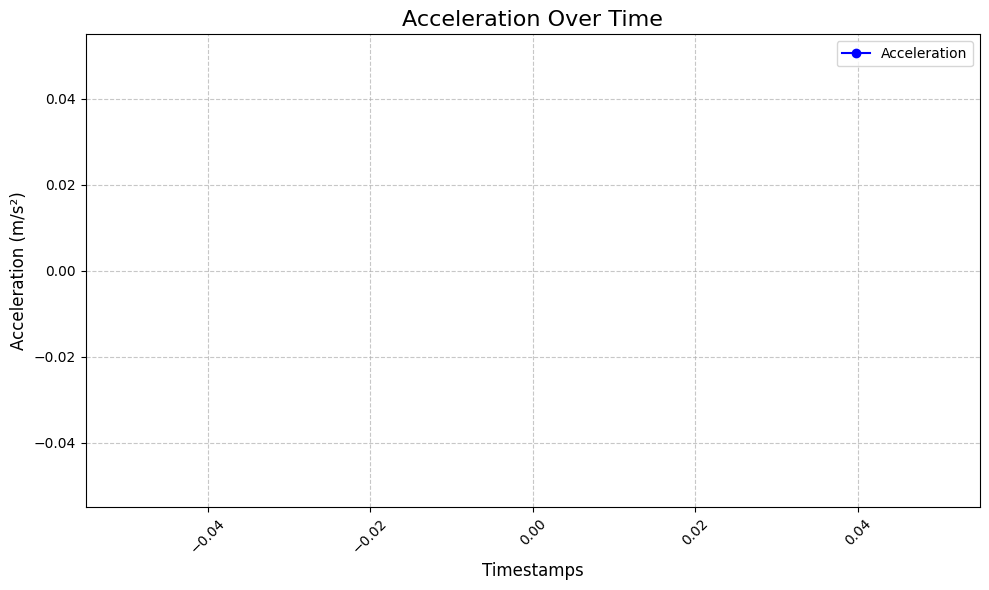

In [137]:
plt.figure(figsize=(10, 6))
plt.plot(df["timestamp"], df["acceleration"], marker="o", linestyle="-", color="b", label="Acceleration")

# Beautify the plot
plt.title("Acceleration Over Time", fontsize=16)
plt.xlabel("Timestamps", fontsize=12)
plt.ylabel("Acceleration (m/s²)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent label clipping

# Show the plot
plt.show()

DataFrame saved to data\data_25995158.csv


In [139]:
acc.stop()